# Import Libraries


In [941]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


## 1. Load and Flatten Raw JSON Dataset

The dataset is stored as a **nested JSON document**, where each record represents a credit application containing:  

- **Applicant information**
- **Financial indicators**
- **Spending behaviour**
- **The final lending decision**

To prepare the data for analysis, the nested structure is **flattened** using `pandas.json_normalize()`, converting nested attributes into columns so that each row corresponds to a credit application and each column represents a specific attribute.


In [942]:
file_path = "../data/raw/raw_credit_applications.json"

with open(file_path, "r") as f:
    raw = json.load(f)

df_raw = pd.json_normalize(raw, sep=".")
print("First 5 rows of the flattened DataFrame:")
print(df_raw.head())


First 5 rows of the flattened DataFrame:
       _id                                  spending_behavior  \
0  app_200  [{'category': 'Shopping', 'amount': 480}, {'ca...   
1  app_037  [{'category': 'Rent', 'amount': 608}, {'catego...   
2  app_215              [{'category': 'Rent', 'amount': 109}]   
3  app_024           [{'category': 'Fitness', 'amount': 575}]   
4  app_184     [{'category': 'Entertainment', 'amount': 463}]   

   processing_timestamp applicant_info.full_name        applicant_info.email  \
0  2024-01-15T00:00:00Z              Jerry Smith   jerry.smith17@hotmail.com   
1                   NaN           Brandon Walker   brandon.walker2@yahoo.com   
2                   NaN              Scott Moore      scott.moore94@mail.com   
3                   NaN               Thomas Lee  thomas.lee6@protonmail.com   
4  2024-01-15T00:00:00Z          Brian Rodriguez   brian.rodriguez86@aol.com   

  applicant_info.ssn applicant_info.ip_address applicant_info.gender  \
0        596-64

## 2. Dataset Overview

Before performing data quality checks, we inspect the structure of the dataset to identify number of variables, their data types, and detect potential isssues such as missing values, inconsistent formats, or type mismatches.

In [943]:
print("DataFrame Info:")
df_raw.info()

print("\nColumn names:")
for col in df_raw.columns:
    print(f"- {col}")


DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   _id                               502 non-null    str    
 1   spending_behavior                 502 non-null    object 
 2   processing_timestamp              62 non-null     str    
 3   applicant_info.full_name          502 non-null    str    
 4   applicant_info.email              502 non-null    str    
 5   applicant_info.ssn                497 non-null    str    
 6   applicant_info.ip_address         497 non-null    str    
 7   applicant_info.gender             501 non-null    str    
 8   applicant_info.date_of_birth      501 non-null    str    
 9   applicant_info.zip_code           501 non-null    str    
 10  financials.annual_income          497 non-null    object 
 11  financials.credit_history_months  502 non-null    int64  
 12  fin

### Initial Observations

From the dataset inspection, several important observations emerge:

• The dataset contains **502 records and 21 variables**. Each record represents a credit application entry, although further validation is required to determine whether all records correspond to unique applications or if duplicate entries are present.

• Some fields contain **missing values**, particularly:
  - `processing_timestamp`
  - `loan_purpose`
  - `decision.interest_rate`
  - `decision.approved_amount`
  - `financials.annual_salary`
  - `notes`

• The column `financials.annual_income` is stored as **object instead of a numeric type**, which may indicate inconsistent formatting or mixed data types.

• Several attributes appear **optional or sparsely populated** (e.g., `loan_purpose`, `notes`), suggesting possible schema inconsistencies or incomplete data collection.

• The field `spending_behavior` remains an **object containing nested structures**, meaning additional transformation may be required for detailed analysis.

These findings confirm the presence of **data quality issues that must be addressed before performing bias analysis** and **governance evaluation.**

## 3. Data Quality Audit
### 3.1 Completeness

#### 3.1.1 Missing Values (NaN)
Missing information reduces the reliability of the data and affects downstream analyses such as bias detection or model evaluation.

The presence of **null values across all variables** is examined to identify and quantify attributes with incomplete records.


In [944]:
missing_count = df_raw.isnull().sum()
missing_percentage = (missing_count / len(df_raw)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing_count,
    "Percentage (%)": missing_percentage.round(2)
}).sort_values("Percentage (%)", ascending=False)

missing_table.head(21) 


,Missing Values,Percentage (%)
notes,500,99.60
financials.annual_salary,497,99.00
loan_purpose,452,90.04
processing_timestamp,440,87.65
decision.rejection_reason,292,58.17
decision.approved_amount,210,41.83
decision.interest_rate,210,41.83
financials.annual_income,5,1.00
applicant_info.ip_address,5,1.00
applicant_info.ssn,5,1.00


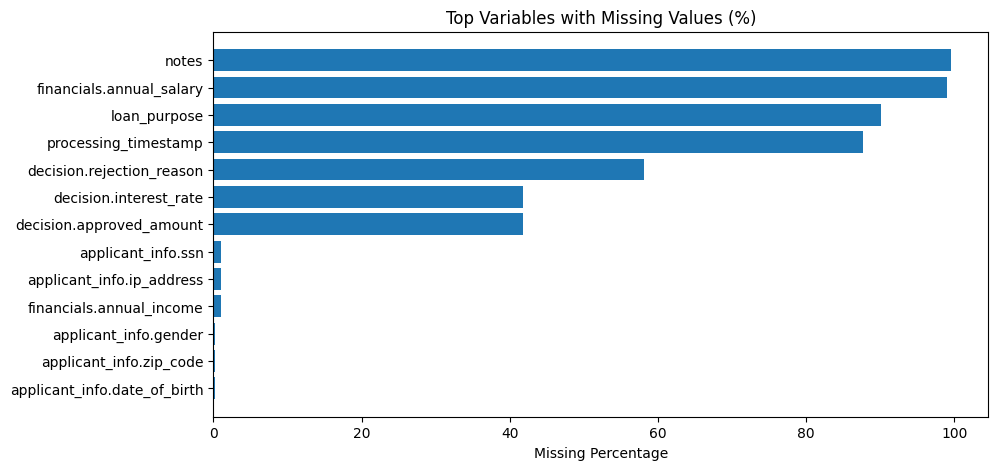

In [945]:
# Display the top 15 variables with the highest missing value percentages
top = missing_table[missing_table["Percentage (%)"] > 0].head(15).sort_values("Percentage (%)")
plt.figure(figsize=(10,5))
plt.barh(top.index, top["Percentage (%)"])
plt.title("Top Variables with Missing Values (%)")
plt.xlabel("Missing Percentage")
plt.show()


#### Findings:

The analysis reveals substantial variation in data completeness across variables.

- Several attributes, such as `notes`, `financials.annual_salary`, `loan_purpose`, and `processing_timestamp`, exhibit very high missingness levels, suggesting that they may be optional or inconsistently captured during data collection.

- Decision-related attributes (`decision.interest_rate` and `decision.approved_amount`) are missing for a subset of records.

- In contrast, financial indicators such as `financials.debt_to_income` and `financials.credit_history_months` show no missing values, indicating that these variables are consistently recorded and likely required for the lending decision process.

#### Structural Missingness vs. Random Missingness

Not all missing values necessarily indicate data quality problems. In some cases, missing values occur by design because certain variables are only relevant under specific conditions.

- The variables `decision.interest_rate` and `decision.approved_amount` are populated only when a loan application is approved.Missing values in these fields therefore represent **structural missingness**, consistent with the decision logic of the lending process.

- Missing values observed in the remaining attributes such as `processing_timestamp`, `loan_purpose`, or certain applicant information fields  represent **non-structural missingness**, which may indicate incomplete data collection or inconsistencies in the data ingestion process.

In [946]:
df_raw.groupby("decision.loan_approved")[["decision.interest_rate","decision.approved_amount"]].count()


,decision.interest_rate,decision.approved_amount
decision.loan_approved,,
False,0,0
True,292,292


#### 3.1.2 Empty String Values
Missing information may also appear in the form of **empty strings ("")**. Unlike null values, empty strings are not automatically detected as missing by most data analysis tools and may therefore obscure incomplete data.

The dataset is therefore examined to identify variables where empty strings are used instead of proper null values.

In [947]:
empty_counts = (df_raw == "").sum()
empty_string_table=pd.DataFrame({"Empty String Count": empty_counts[empty_counts > 0]}).sort_values("Empty String Count",ascending=False)
empty_string_table.head()


,Empty String Count
applicant_info.email,7
applicant_info.date_of_birth,4
applicant_info.gender,2
applicant_info.zip_code,1


#### Findings:

This analysis shows that in certain variables missing information is enconded as strings rather than proper null entries, indicating inconsistencies in how missing data is represented and may hinder accurate detection of incomplete records during analysis.

To ensure consistent handling of missing values, empty string entries are standardised by converting them to null values (`NaN`). 

In [948]:
# First Remediation Step: Convert empty string values to null values
df_raw = df_raw.replace("", np.nan)
remaining_empty_strings = (df_raw == "").sum().sum() # verify if empty string entries were successfully converted to NaN
print("Remaining empty string values:", remaining_empty_strings) 


Remaining empty string values: 0


Following this first remediation step, missing values in the dataset are represented consistently using NaN values, enabling more reliable completeness analysis.

### 3.2 Consistency

Inconsistent encodings, formats, or schema definitions can lead to inaccurate aggregations and misleading analytical results. 

The dataset is examined for inconsistencies in:
- Categorical Encodings
- Date Formats
- Schema Structure

#### 3.2.1 Categorical Value Consistency

Categorical variables should use a consistent representation for each category. The `applicant_info.gender` variable is examined to identify potential inconsistencies in category encoding.

In [949]:
print("\nUnique values and counts for 'applicant_info.gender':")
print(df_raw['applicant_info.gender'].value_counts(dropna=False))



Unique values and counts for 'applicant_info.gender':
applicant_info.gender
Male      195
Female    193
F          58
M          53
NaN         3
Name: count, dtype: int64


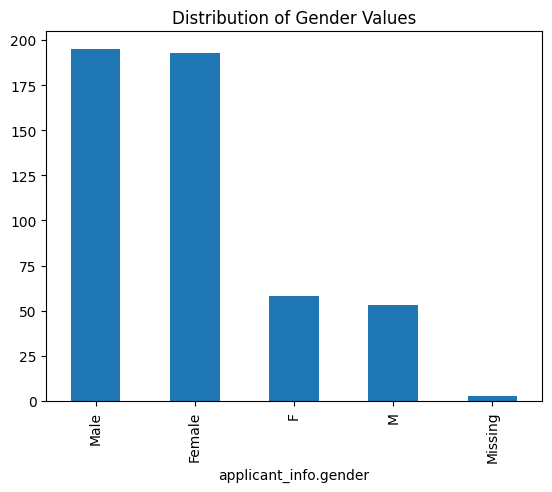

In [950]:
df_raw["applicant_info.gender"].fillna("Missing").astype(str).value_counts().plot(kind="bar")
plt.title("Distribution of Gender Values")
plt.show()


#### Findings:

The gender variable contains multiple encodings for the same categories, including `"Male"` and `"M"`, as well as `"Female"` and `"F"`. Additionally, three records contain missing values.

Such inconsistencies may distort statistical analysis and bias detection if treated as separate categories. Standardising categorical values is therefore necessary to ensure consistent interpretation across the dataset.

#### 3.2.2 Date Format Consistency

Date variables should also follow a consistent format to enable reliable parsing and chronological analysis.

The `applicant_info.date_of_birth` field is inspected to identify potential inconsistencies in date representation.

In [ ]:
print("Sample of Date of Birth Values:")
df_raw["applicant_info.date_of_birth"].dropna().astype(str).sample(15, random_state=42)


Sample of Date of Birth Values:


488    1995-02-22
74     11/03/1967
232    1980/12/21
176    1987-10-23
238    17/02/1966
426    1999-10-05
156    1975-04-14
56     1985-09-06
324    1997/08/31
9      1989-10-10
105    1999/06/16
262    1997/03/01
353    1987-09-16
193    1981-09-28
102    1972-12-28
Name: applicant_info.date_of_birth, dtype: str

#### Findings

The date of birth variable contains multiple formatting styles, including ISO formats (`YYYY-MM-DD`) and alternatives such as `DD/MM/YYYY` and `YYYY/MM/DD`.

Mixed formats may lead to parsing errors or incorrect age calculations in downstream analysis. Standardising the date format would improve temporal data processing.

#### 3.2.3 Schema Consistency

Consistency should also be maintained at the schema level. Attributes representing the same concept should not appear under multiple column names.

The dataset is inspected to identify variables that may represent similar information but are stored in separate fields.

In [952]:
print("Count of non-null values in variables with the same concept:")
df_raw[["financials.annual_income","financials.annual_salary"]].count()


Count of non-null values in variables with the same concept:


financials.annual_income    497
financials.annual_salary      5
dtype: int64

#### Findings:

The dataset contains both `financials.annual_income` and `financials.annual_salary`, which appear to represent similar financial attributes.

However, the two variables are populated very differently. While `financials.annual_income` contains values for the majority of records, `financials.annual_salary` contains only a small number of entries.

This pattern suggests a schema inconsistency, potentially resulting from incomplete schema migration or inconsistent data ingestion practices.

In [953]:
print("Main Consistency Issues Identified:")
pd.DataFrame({
    "Issue Type": [
        "Categorical encoding inconsistency",
        "Date format inconsistency",
        "Schema inconsistency"
    ],
    "Affected Variables": [
        "applicant_info.gender",
        "applicant_info.date_of_birth",
        "financials.annual_income / financials.annual_salary"
    ]
})


Main Consistency Issues Identified:


,Issue Type,Affected Variables
0,Categorical encoding inconsistency,applicant_info.gender
1,Date format inconsistency,applicant_info.date_of_birth
2,Schema inconsistency,financials.annual_income / financials.annual_s...


### 3.3 Validity
Invalid data may arise from type mismatches (e.g., temporal values stored as text or numeric values stored as strings) or from numeric values falling outside plausible business ranges.

This section evaluates:

- whether attributes can be interpreted using appropriate numeric or temporal types  
- whether numeric values fall within logically plausible 

The goal is to identify potential issues that will be addressed during the data cleaning stage.

#### 3.3.1 Data Type Validity

Variables should be stored using appropriate data types to ensure reliable computation and analysis. 
However, during data ingestion or transformation processes, attributes containing numerical or temporal information may be stored as text.

This section identifies variables whose stored type may not match their intended semantic type.

In [ ]:
print("Data types of each attribute:")
print(df_raw.dtypes)


Data types of each attribute:
_id                                     str
spending_behavior                    object
processing_timestamp                    str
applicant_info.full_name                str
applicant_info.email                    str
applicant_info.ssn                      str
applicant_info.ip_address               str
applicant_info.gender                   str
applicant_info.date_of_birth            str
applicant_info.zip_code                 str
financials.annual_income             object
financials.credit_history_months      int64
financials.debt_to_income           float64
financials.savings_balance            int64
decision.loan_approved                 bool
decision.rejection_reason               str
loan_purpose                            str
decision.interest_rate              float64
decision.approved_amount            float64
financials.annual_salary            float64
notes                                   str
dtype: object


#### Findings:

Most attributes follow appropriate data types.  However, the following variables expected to support numerical or temporal analysis are stored as string or object types:
- `financials.annual_income`: appears as an object rather than a numeric variable  
- `applicant_info.date_of_birth` and `processing_timestamp`: stored as strings instead of datetime objects

These representations require additional validation to determine whether their values can still be correctly interpreted.

Additionally, the nested structure of `spending_behavior` must be validated to ensure that spending categories are stored as strings and transaction amounts as numeric values, allowing the variable to be used in subsequent analytical computations.

In [ ]:
print("Current financials.annual_income dtype:", df_raw["financials.annual_income"].dtype)
income_numeric = pd.to_numeric(df_raw["financials.annual_income"], errors="coerce")
non_convertible_values = df_raw["financials.annual_income"].notna() & income_numeric.isna() # Identify values that could not be converted
print("Non-convertible income values:", non_convertible_values.sum())
print("Missing income values:", df_raw["financials.annual_income"].isna().sum())

# Second Remediation Step required for Numeric Range Validity. 
if non_convertible_values.sum() == 0:
    df_raw["financials.annual_income"] = income_numeric

print("Current financials.annual_income dtype:", df_raw["financials.annual_income"].dtype)


Current financials.annual_income dtype: object
Non-convertible income values: 0
Missing income values: 5
Current financials.annual_income dtype: float64


#### Findings:

The variable `financials.annual_income` is initially stored as an **object** instead of a numeric type.

The validation check confirms that non-null values can be interpreted as numeric values, indicating that the object type is primarily due to the presence of missing values rather than inconsistent formatting.

The column is therefore **converted to a numeric type** to support subsequent validation steps, namely numeric range checks.

In [ ]:
temporal_columns = [
    "processing_timestamp",
    "applicant_info.date_of_birth"
]

results = []

for col in temporal_columns:
    parsed = pd.to_datetime(df_raw[col], errors="coerce")

    invalid_dates = df_raw[col].notna().sum() - parsed.notna().sum()

    results.append({
        "column": col,
        "stored_dtype": df_raw[col].dtype,
        "missing_values": df_raw[col].isna().sum(),
        "non_parsable_dates": invalid_dates
    })

pd.DataFrame(results)


,column,stored_dtype,missing_values,non_parsable_dates
0,processing_timestamp,str,440,0
1,applicant_info.date_of_birth,str,5,157


#### Findings:

Temporal attributes such as `applicant_info.date_of_birth` and `processing_timestamp` are stored as string values.

Results indicate that for `processing_timestamp`, the string type is primarily due to a high number of missing values, while `applicant_info.date_of_birth` contains a significant number of non-parsable entries (157), suggesting formatting inconsistencies.

Converting these attributes to datetime types after proper cleaning would improve reliability for time-based analysis.

In [ ]:
# check the strcture of spending_behavior due to possibility of data type issues
invalid_category_type = 0
invalid_amount_type = 0
invalid_structure = 0

for entry in df_raw["spending_behavior"].dropna():

    # ensure the entry is a list of transactions
    if not isinstance(entry, list):
        invalid_structure += 1
        continue

    for transaction in entry:

        if not isinstance(transaction, dict):
            invalid_structure += 1
            continue

        # check category type
        if not isinstance(transaction.get("category"), str):
            invalid_category_type += 1

        # check amount type
        if not isinstance(transaction.get("amount"), int):
            invalid_amount_type += 1


print("Invalid structures:", invalid_structure)
print("Invalid category types (not string):", invalid_category_type)
print("Invalid amount types (not integer):", invalid_amount_type)


Invalid structures: 0
Invalid category types (not string): 0
Invalid amount types (not integer): 0


#### Findings:
The variable `spending_behavior` is stored as an object because it contains nested structured information (JSON-like dictionaries).  
Its structure inspection shows the nested values - transaction amounts or categories - can be interpreted as string or numeric values where appropriate.

### 3.3.2 Numeric Range Validity

Numeric attributes should fall within logically plausible ranges. Values that are extreme or illogical (e.g., negative balances or ratios outside expected limits) may indicate data entry errors or data processing issues.

This section inspects the distribution of numeric variables and highlights potential anomalies that require further review.

In [958]:
numerical_columns = df_raw.select_dtypes(include=["int64", "float64"]).columns
print("\nDescriptive statistics for numerical columns:")
df_raw[numerical_columns].describe().round(2)



Descriptive statistics for numerical columns:


,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.interest_rate,decision.approved_amount,financials.annual_salary
count,497.00,502.00,502.00,502.00,292.00,292.00,5.00
mean,82705.10,50.40,0.25,29493.50,4.56,47845.89,69200.00
std,28101.98,31.23,0.14,16775.31,1.16,18103.75,22664.95
min,0.00,-10.00,0.05,-5000.00,2.50,15000.00,45000.00
25%,63000.00,27.25,0.15,17258.25,3.50,34000.00,46000.00
50%,81000.00,48.00,0.23,27385.50,4.55,48000.00,75000.00
75%,101000.00,72.00,0.35,38251.50,5.60,62250.00,86000.00
max,171000.00,133.00,1.85,88078.00,6.50,80000.00,94000.00


In [ ]:
range_checks = []

for col in numeric_columns:

    negative_values = (df_raw[col] < 0).sum()

    range_checks.append({
        "column": col,
        "min": df_raw[col].min(),
        "max": df_raw[col].max(),
        "negative_values": negative_values
    })

pd.DataFrame(range_checks)


,column,min,max,negative_values
0,financials.annual_income,0.00,171000.00,0
1,financials.credit_history_months,-10.00,133.00,2
2,financials.debt_to_income,0.05,1.85,0
3,financials.savings_balance,-5000.00,88078.00,1


In [ ]:
invalid_credit_history = (df_raw["financials.credit_history_months"] < 0).sum()

invalid_dti = (
    (df_raw["financials.debt_to_income"] < 0) |
    (df_raw["financials.debt_to_income"] > 1)
).sum()

invalid_savings = (df_raw["financials.savings_balance"] < 0).sum()

print("Negative credit history months:", invalid_credit_history)
print("Debt-to-income outside [0,1]:", invalid_dti)
print("Negative savings balance:", invalid_savings)


Negative credit history months: 2
Debt-to-income outside [0,1]: 1
Negative savings balance: 1


#### Findings:

The range checks reveal a small number of values outside logically plausible limits:

- `financials.credit_history_months` contains negative values (min = -10), with **2 records** below zero.
- `financials.debt_to_income` includes values **above the expected ratio range [0,1]** (max = 1.85), affecting **1 record**.
- `financials.savings_balance` contains **1 negative value** (min = -5000).

These anomalies may indicate data entry errors or calculation issues and should be reviewed during the data cleaning stage before bias and governance analysis.


### 3.4 Uniqueness

In [972]:
# Duplicate entries based on application ID
duplicate_count = df_raw["_id"].duplicated().sum()
duplicate_percentage = (duplicate_count / len(df_raw) * 100).round(2)
print("Duplicate application IDs:", duplicate_count)
print("Percentage of duplicate application IDs:", duplicate_percentage)

duplicate_ids = df_raw[df_raw["_id"].duplicated(keep=False)]["_id"].unique()
print("\nDuplicated IDs:", duplicate_ids)

duplicated_records = df_raw[df_raw["_id"].isin(duplicate_ids)] # full duplicated records
duplicated_records


Duplicate application IDs: 2
Percentage of duplicate application IDs: 0.4

Duplicated IDs: <StringArray>
['app_042', 'app_001']
Length: 2, dtype: str


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
8,app_042,"[{'category': 'Insurance', 'amount': 153}, {'c...",NaN,Joseph Lopez,joseph.lopez1@gmail.com,652-70-5530,192.168.91.142,Male,1990-05-04,10044,...,43,0.41,15974,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
354,app_042,"[{'category': 'Insurance', 'amount': 153}, {'c...",NaN,Joseph Lopez,joseph.lopez1@gmail.com,652-70-5530,192.168.91.142,Male,1990-05-04,10044,...,43,0.41,15974,False,algorithm_risk_score,NaN,NaN,NaN,NaN,RESUBMISSION
383,app_001,"[{'category': 'Fitness', 'amount': 576}]",NaN,Stephanie Nguyen,stephanie.nguyen47@mail.com,427-90-1892,10.121.120.213,Female,1986-05-27,90230,...,37,0.42,0,False,high_dti_ratio,NaN,NaN,NaN,NaN,NaN
455,app_001,"[{'category': 'Fitness', 'amount': 576}]",NaN,Stephanie Nguyen,stephanie.nguyen47@mail.com,NaN,NaN,NaN,NaN,NaN,...,37,0.42,0,False,high_dti_ratio,NaN,NaN,NaN,NaN,DUPLICATE_ENTRY_ERROR


#### Findings:
The uniqueness check identifies **2 duplicated application IDs**, indicating that the applications **app_001** and **app_042** appear more than once in the dataset, due to duplicate entry error and resubmission, consequently.

Duplicate records can lead to biased statistics and incorrect model training results. Deduplication should therefore be performed during the data cleaning stage, ensuring each application is uniquely represented.